<a href="https://colab.research.google.com/github/acatalanb/ImageMetricsProject/blob/main/VideoAnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers opencv-python-headless scikit-learn matplotlib seaborn pandas

print("✅ Installed! Use Runtime → Change runtime type → GPU")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Installed! Use Runtime → Change runtime type → GPU


In [56]:
%%writefile metrics_manager.py
"""
metrics_manager.py - Model Performance Evaluation and Visualization

This module provides the MetricsManager class for comprehensive model evaluation:
- Computes classification metrics (accuracy, sensitivity, specificity, precision, F1, AUC)
- Handles both binary and multi-class classification scenarios
- Generates confusion matrix and ROC curve visualizations
- Saves metrics to JSON files for persistent storage and later retrieval
- Tracks training time for performance benchmarking

All metrics and visualizations are saved to a 'cache' directory organized by model name.

Author: Video Metrics Project Team
Created: 2026-03-18
Version: 1.0.0-alpha
"""

import time
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score


class MetricsManager:
    def __init__(self, model_name):
        # Create a safe filename safe string (e.g. "3D CNN" -> "3D_CNN")
        self.cache_dir = 'cache'
        os.makedirs(self.cache_dir, exist_ok=True)
        self.safe_name = model_name.replace(" ", "_")
        self.metrics_file = os.path.join(self.cache_dir, f"metrics_{self.safe_name}.json")
        self.cm_file = os.path.join(self.cache_dir, f"cm_{self.safe_name}.png")
        self.roc_file = os.path.join(self.cache_dir, f"roc_{self.safe_name}.png")
        self.start_time = None
        self.end_time = None

    def start_training_timer(self):
        self.start_time = time.time()

    def stop_training_timer(self):
        self.end_time = time.time()
        return self.end_time - self.start_time

    def compute_metrics(self, y_true, y_pred, y_probs):
        """Calculates a comprehensive dictionary of metrics."""

        # 1. Confusion Matrix elements
        cm = confusion_matrix(y_true, y_pred)

        # Check if binary classification
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        else:
            # For multi-class, specificity isn't directly applicable
            specificity = None

        # 2. Derived Metrics
        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred, average='binary' if cm.shape == (2, 2) else 'macro', zero_division=0)
        precision = precision_score(y_true, y_pred, average='binary' if cm.shape == (2, 2) else 'macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='binary' if cm.shape == (2, 2) else 'macro', zero_division=0)

        # 3. AUC calculation
        try:
            fpr, tpr, _ = roc_curve(y_true, y_probs)
            roc_auc = auc(fpr, tpr)
        except:
            roc_auc = 0.5
            fpr, tpr = [0, 1], [0, 1]

        return {
            "accuracy": accuracy,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "f1_score": f1,
            "auc": roc_auc,
            "confusion_matrix": cm.tolist(),  # Convert to list for JSON
            "roc_data": {"fpr": fpr.tolist(), "tpr": tpr.tolist()}
        }

    def save_metrics(self, metrics_dict, training_time):
        """Saves metrics and training time to JSON."""
        metrics_dict["training_time_seconds"] = training_time
        metrics_dict["training_timestamp"] = time.ctime()

        with open(self.metrics_file, "w") as f:
            json.dump(metrics_dict, f, indent=4)
        print(f"Metrics saved to {self.metrics_file}")

    def load_metrics(self):
        """Loads the JSON metrics from disk."""
        if os.path.exists(self.metrics_file):
            with open(self.metrics_file, "r") as f:
                return json.load(f)
        return None

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Normal', 'Abnormal'],
                    yticklabels=['Normal', 'Abnormal'])
        plt.title(f'Confusion Matrix: {self.safe_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(self.cm_file)
        plt.close()

    def plot_roc_curve(self, fpr, tpr, roc_auc):
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve: {self.safe_name}')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(self.roc_file)
        plt.close()

Overwriting metrics_manager.py


In [57]:
%%writefile model.py
"""
model.py - Video Classification Model Architectures

This module contains three different deep learning architectures for video classification:
1. CNN-LSTM: Combines ResNet18 feature extraction with LSTM temporal modeling
2. 3D CNN: Uses ResNet R(2+1)D for spatiotemporal feature learning
3. Video Transformer: Leverages VideoMAE pretrained transformer architecture

The module provides a factory function get_model() to instantiate any of these architectures.

Author: Video Metrics Project Team
Created: 2026-03-18
Version: 1.0.0-alpha
"""

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# Try importing Transformers (Handle case if user hasn't installed it)
try:
    from transformers import VideoMAEForVideoClassification

    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False


# ==========================================
# 1. CNN-LSTM (The Baseline)
# ==========================================
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=2, lstm_hidden_size=256, lstm_layers=2):
        super(CNNLSTM, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(input_size=512, hidden_size=lstm_hidden_size, num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, x):
        # Input: (Batch, Seq, C, H, W)
        batch_size, seq_len, c, h, w = x.size()
        c_in = x.view(batch_size * seq_len, c, h, w)
        cnn_out = self.feature_extractor(c_in)
        cnn_out = cnn_out.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(cnn_out)
        return self.fc(lstm_out[:, -1, :])


# ==========================================
# 2. 3D CNN (ResNet R(2+1)D)
# ==========================================
class ResNet3D(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet3D, self).__init__()
        weights = R2Plus1D_18_Weights.DEFAULT
        self.model = r2plus1d_18(weights=weights)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        # Input: (Batch, Seq, C, H, W) -> Needed: (Batch, C, Seq, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        return self.model(x)


# ==========================================
# 3. Video Transformer (VideoMAE)
# ==========================================
class VideoTransformer(nn.Module):
    def __init__(self, num_classes=2):
        super(VideoTransformer, self).__init__()
        if not TRANSFORMERS_AVAILABLE:
            raise ImportError("Please run 'pip install transformers' to use this model.")

        # Using a lightweight VideoMAE model
        self.model = VideoMAEForVideoClassification.from_pretrained(
            "MCG-NJU/videomae-base-finetuned-kinetics",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    def forward(self, x):
        # Input: (Batch, Seq, C, H, W)
        # HuggingFace expects 'pixel_values' argument
        outputs = self.model(pixel_values=x)
        return outputs.logits


# ==========================================
# Factory Helper
# ==========================================
def get_model(model_name, num_classes=2):
    if model_name == "CNN-LSTM":
        return CNNLSTM(num_classes=num_classes)
    elif model_name == "3D CNN":
        return ResNet3D(num_classes=num_classes)
    elif model_name == "Video Transformer":
        return VideoTransformer(num_classes=num_classes)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

Overwriting model.py


In [58]:
%%writefile train.py
"""
train.py - Model Training Pipeline (Colab version)
"""
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import cv2
import glob
import os
import numpy as np
from model import get_model
from metrics_manager import MetricsManager

# --- CONFIG (updated for Colab / Google Drive) ---
IMG_SIZE = 224
SEQ_LEN = 16
BATCH_SIZE = 8
DEFAULT_ROOT = "/content/drive/MyDrive/VideoDataset"   # Updated dataset root

class VideoDataset(Dataset):
    def __init__(self, root_dir=DEFAULT_ROOT):
        self.video_paths = []
        self.labels = []
        # Adjusted glob.glob paths to include 'kvasir' subfolder
        norm_files = glob.glob(os.path.join(root_dir, 'kvasir', 'normal', '*.mp4'))
        abnorm_files = glob.glob(os.path.join(root_dir, 'kvasir', 'abnormal', '*.mp4'))
        self.video_paths.extend(norm_files + abnorm_files)
        self.labels.extend([0] * len(norm_files) + [1] * len(abnorm_files))

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < SEQ_LEN:
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = frame.astype(np.float32) / 255.0
                frame = np.transpose(frame, (2, 0, 1))
                frames.append(frame)
            else:
                frames.append(np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32))
        cap.release()
        return torch.tensor(np.array(frames[:SEQ_LEN])), torch.tensor(label)


def run_training(model_name, epochs=5, status_placeholder=None, dataset_path=None):
    if dataset_path is None:
        dataset_path = DEFAULT_ROOT
    metrics_manager = MetricsManager(model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✅ Training on {device}")

    # Adjusted existence check for 'kvasir' subfolder
    if not os.path.exists(os.path.join(dataset_path, 'kvasir')):
        return f"Error: Dataset not found at {os.path.join(dataset_path, 'kvasir')}"

    full_dataset = VideoDataset(root_dir=dataset_path)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = get_model(model_name).to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    metrics_manager.start_training_timer()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for videos, labels in train_loader:
            videos, labels = videos.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {running_loss / len(train_loader):.4f}")

    total_time = metrics_manager.stop_training_timer()

    # Save model
    os.makedirs('cache', exist_ok=True)
    safe_name = model_name.replace(" ", "_")
    save_path = f"cache/model_{safe_name}.pth"
    torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), save_path)

    # Evaluation & metrics
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            _, preds = torch.max(probs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    stats = metrics_manager.compute_metrics(all_labels, all_preds, all_probs)
    metrics_manager.save_metrics(stats, total_time)
    metrics_manager.plot_confusion_matrix(np.array(stats['confusion_matrix']))
    metrics_manager.plot_roc_curve(stats['roc_data']['fpr'], stats['roc_data']['tpr'], stats['auc'])

    print(f"✅ Training complete! Model saved: {save_path}")
    return save_path

Overwriting train.py


In [59]:
%%writefile inference.py
"""
inference.py - Live prediction (Colab version)
"""
import torch
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from model import get_model
from google.colab import files
from IPython.display import Image, Video, display

IMG_SIZE = 224
SEQ_LEN = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def process_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, frame_count // SEQ_LEN)
    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame.astype(np.float32) / 255.0
            frame = np.transpose(frame, (2, 0, 1))
            frames.append(frame)
        else:
            frames.append(np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32))
    cap.release()
    return torch.tensor(np.array(frames)).unsqueeze(0).to(DEVICE)

class VideoPredictor:
    def __init__(self, model_name, model_path="cache/model_CNN-LSTM.pth"):
        self.model = get_model(model_name)
        state_dict = torch.load(model_path, map_location=DEVICE)
        if list(state_dict.keys())[0].startswith('module.'):
            state_dict = {k[7:]: v for k, v in state_dict.items()}
        self.model.load_state_dict(state_dict)
        self.model.to(DEVICE)
        self.model.eval()
        print(f"✅ Loaded {model_name} on {DEVICE}")

    def predict(self, video_path=None):
        if video_path is None:
            print("Upload a video...")
            uploaded = files.upload()
            if not uploaded:
                return None
            video_path = list(uploaded.keys())[0]

        display(Video(video_path, embed=True))

        t0 = time.time()
        input_tensor = process_video(video_path)
        t1 = time.time()

        with torch.no_grad():
            outputs = self.model(input_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, 1)

        inference_time = time.time() - t1

        result = {'Normal': probs[0][0].item(), 'Abnormal': probs[0][1].item()}
        label = "🚨 ANOMALY DETECTED" if pred.item() == 1 else "✅ NORMAL SCAN"

        print(f"\n{label} (Confidence: {conf.item():.1%})")
        print(f"Inference time: {inference_time*1000:.0f} ms")

        # Bar chart
        plt.figure(figsize=(6,4))
        plt.bar(result.keys(), result.values(), color=['#2ecc71', '#e74c3c'])
        plt.ylabel("Probability")
        plt.title("Prediction Confidence")
        plt.ylim(0, 1)
        plt.show()

        return result

Overwriting inference.py


In [64]:
%%writefile app.py

from metrics_manager import MetricsManager
import json
from IPython.display import Image, display
import os

# Assuming the last trained model was '3D CNN'
model_name = "3D CNN"
metrics_manager = MetricsManager(model_name)

# Load the saved metrics
metrics = metrics_manager.load_metrics()

if metrics:
    print(f"--- Metrics for {model_name} ---")
    print(f"Accuracy: {metrics.get('accuracy', 'N/A'):.4f}")
    print(f"Sensitivity: {metrics.get('sensitivity', 'N/A'):.4f}")
    print(f"Specificity: {metrics.get('specificity', 'N/A'):.4f}")
    print(f"Precision: {metrics.get('precision', 'N/A'):.4f}")
    print(f"F1 Score: {metrics.get('f1_score', 'N/A'):.4f}")
    print(f"AUC: {metrics.get('auc', 'N/A'):.4f}")
    print(f"Training Time: {metrics.get('training_time_seconds', 'N/A'):.2f} seconds")
    print(f"Training Timestamp: {metrics.get('training_timestamp', 'N/A')}")

    # Display confusion matrix and ROC curve images
    cm_path = f"cache/cm_{metrics_manager.safe_name}.png"
    roc_path = f"cache/roc_{metrics_manager.safe_name}.png"

    if os.path.exists(cm_path):
        print("\n--- Confusion Matrix ---")
        display(Image(filename=cm_path))
    else:
        print(f"Confusion Matrix image not found at {cm_path}")

    if os.path.exists(roc_path):
        print("\n--- ROC Curve ---")
        display(Image(filename=roc_path))
    else:
        print(f"ROC Curve image not found at {roc_path}")
else:
    print(f"No metrics found for {model_name}. Please ensure the model has been trained and metrics saved.")

Overwriting app.py


✅ Training on cuda
Epoch 1/5 - Loss: 0.2115
Epoch 2/5 - Loss: 0.1298
Epoch 3/5 - Loss: 0.0940
Epoch 4/5 - Loss: 0.0370
Epoch 5/5 - Loss: 0.0430
Metrics saved to cache/metrics_3D_CNN.json
✅ Training complete! Model saved: cache/model_3D_CNN.pth
✅ Loaded 3D CNN on cuda
Upload a video...


Saving 2fc3db471f9d44c0_5478_Ulcer.mp4 to 2fc3db471f9d44c0_5478_Ulcer.mp4



🚨 ANOMALY DETECTED (Confidence: 100.0%)
Inference time: 6 ms


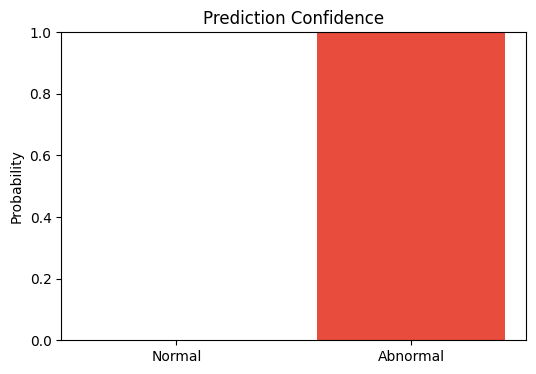

--- Metrics for 3D CNN ---
Accuracy: 0.9386
Sensitivity: 0.8333
Specificity: 0.9460
Precision: 0.5208
F1 Score: 0.6410
AUC: 0.9532
Training Time: 580.12 seconds
Training Timestamp: Mon Mar 23 15:25:21 2026

--- Confusion Matrix ---
Traceback (most recent call last):
  File "/content/app.py", line 31, in <module>
    display(Image(filename=cm_path))
    ^^^^^^^
NameError: name 'display' is not defined


In [63]:
# 1. Train a model
from train import run_training
run_training("3D CNN", epochs=5)          # or "CNN-LSTM" or "Video Transformer"

# 2. Run live prediction
from inference import VideoPredictor
predictor = VideoPredictor("3D CNN", model_path="cache/model_3D_CNN.pth")      # change model name if needed
predictor.predict()                       # uploads and analyzes video


--- Metrics for 3D CNN ---
Accuracy: 0.9386
Sensitivity: 0.8333
Specificity: 0.9460
Precision: 0.5208
F1 Score: 0.6410
AUC: 0.9532
Training Time: 580.12 seconds

--- Confusion Matrix ---


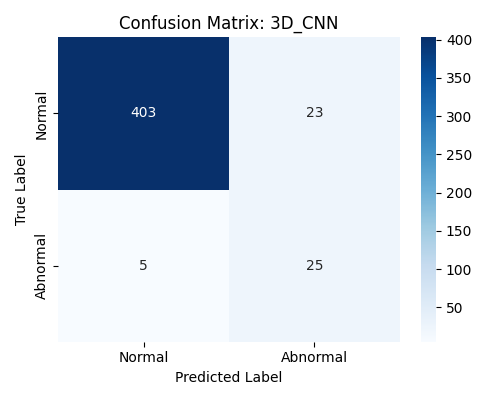


--- ROC Curve ---


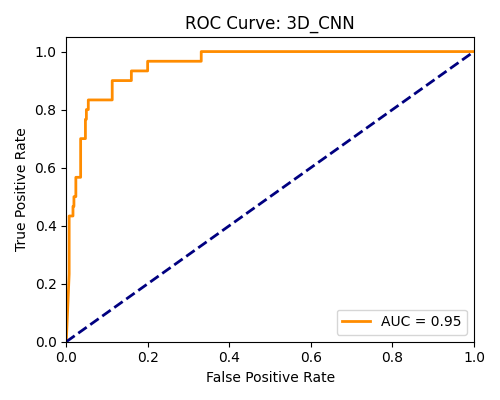

In [68]:
from metrics_manager import MetricsManager
from IPython.display import Image, display
import os

# Configuration
model_name = "3D CNN"
metrics_manager = MetricsManager(model_name)

# Load and Display
metrics = metrics_manager.load_metrics()

if metrics:
    print(f"--- Metrics for {model_name} ---")
    print(f"Accuracy: {metrics.get('accuracy', 'N/A'):.4f}")
    print(f"Sensitivity: {metrics.get('sensitivity', 'N/A'):.4f}")
    print(f"Specificity: {metrics.get('specificity', 'N/A'):.4f}")
    print(f"Precision: {metrics.get('precision', 'N/A'):.4f}")
    print(f"F1 Score: {metrics.get('f1_score', 'N/A'):.4f}")
    print(f"AUC: {metrics.get('auc', 'N/A'):.4f}")
    print(f"Training Time: {metrics.get('training_time_seconds', 'N/A'):.2f} seconds")

    cm_path = f"cache/cm_{metrics_manager.safe_name}.png"
    roc_path = f"cache/roc_{metrics_manager.safe_name}.png"

    if os.path.exists(cm_path):
        print("\n--- Confusion Matrix ---")
        display(Image(filename=cm_path))

    if os.path.exists(roc_path):
        print("\n--- ROC Curve ---")
        display(Image(filename=roc_path))
else:
    print(f"No metrics found for {model_name}. Please ensure the model has been trained.")